In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'../data/processed/matches_merged.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,home_rank,home_points,away_rank,away_points,rank_diff
0,2001-07-15,Brazil,Peru,2.0,0.0,Copa América,Cali,Colombia,True,H,NaN,NaN,NaN,NaN,NaN
1,2001-07-15,Congo,Ivory Coast,1.0,1.0,FIFA World Cup qualification,Pointe-Noire,Congo,False,D,NaN,NaN,NaN,NaN,NaN
2,2001-07-15,DR Congo,Tunisia,0.0,3.0,FIFA World Cup qualification,Kinshasa,DR Congo,False,A,NaN,NaN,NaN,NaN,NaN
3,2001-07-15,Ghana,Sudan,1.0,0.0,FIFA World Cup qualification,Accra,Ghana,False,H,NaN,NaN,NaN,NaN,NaN
4,2001-07-15,Paraguay,Mexico,0.0,0.0,Copa América,Cali,Colombia,True,D,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23710 entries, 0 to 23709
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         23710 non-null  str    
 1   home_team    23710 non-null  str    
 2   away_team    23710 non-null  str    
 3   home_score   23708 non-null  float64
 4   away_score   23708 non-null  float64
 5   tournament   23710 non-null  str    
 6   city         23710 non-null  str    
 7   country      23710 non-null  str    
 8   neutral      23710 non-null  bool   
 9   result       23710 non-null  str    
 10  home_rank    21932 non-null  float64
 11  home_points  21935 non-null  float64
 12  away_rank    21790 non-null  float64
 13  away_points  21796 non-null  float64
 14  rank_diff    20916 non-null  float64
dtypes: bool(1), float64(7), str(7)
memory usage: 2.6 MB


In [4]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23710 entries, 0 to 23709
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         23710 non-null  datetime64[us]
 1   home_team    23710 non-null  str           
 2   away_team    23710 non-null  str           
 3   home_score   23708 non-null  float64       
 4   away_score   23708 non-null  float64       
 5   tournament   23710 non-null  str           
 6   city         23710 non-null  str           
 7   country      23710 non-null  str           
 8   neutral      23710 non-null  bool          
 9   result       23710 non-null  str           
 10  home_rank    21932 non-null  float64       
 11  home_points  21935 non-null  float64       
 12  away_rank    21790 non-null  float64       
 13  away_points  21796 non-null  float64       
 14  rank_diff    20916 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(7), str(6)
memory usage: 

### Handling Missing Values

In [5]:
df.isnull().sum()

date              0
home_team         0
away_team         0
home_score        2
away_score        2
tournament        0
city              0
country           0
neutral           0
result            0
home_rank      1778
home_points    1775
away_rank      1920
away_points    1914
rank_diff      2794
dtype: int64

In [6]:
missing_rank = df[df['home_rank'].isna()]
print(missing_rank['date'].dt.year.value_counts().sort_index())

date
2001     21
2002     44
2003     74
2004     69
2005     57
2006     72
2007     57
2008     63
2009     70
2010     67
2011     87
2012     91
2013     51
2014     86
2015    110
2016     93
2017     96
2018    101
2019    121
2020      4
2021     24
2022     53
2023    112
2024     75
2025     63
2026     17
Name: count, dtype: int64


In [7]:
print(missing_rank['home_team'].value_counts().head(15))

home_team
Martinique                          39
Jersey                              33
Saint Kitts and Nevis               32
Guadeloupe                          31
French Guiana                       26
Zanzibar                            25
DR Congo                            24
Curaçao                             24
Guernsey                            22
Kyrgyzstan                          21
Alderney                            18
Réunion                             18
Saint Lucia                         17
Gibraltar                           15
Saint Vincent and the Grenadines    15
Name: count, dtype: int64


### Droping missing rows

I choosed to drop because as in `home_team` names this are teams that will not play the FIFA World cup, so its fine to drop them

In [8]:
df.dropna(inplace=True)
print(f'Shape: {df.shape}')
df.isnull().sum()

Shape: (20914, 15)


date           0
home_team      0
away_team      0
home_score     0
away_score     0
tournament     0
city           0
country        0
neutral        0
result         0
home_rank      0
home_points    0
away_rank      0
away_points    0
rank_diff      0
dtype: int64

result
H    10027
A     5956
D     4931
Name: count, dtype: int64


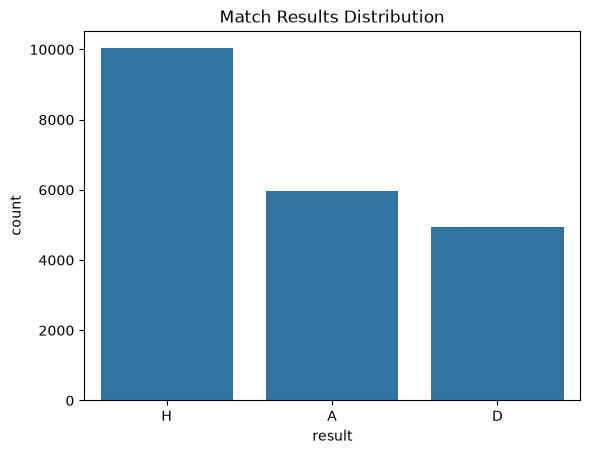

In [9]:
print(df['result'].value_counts())
sns.countplot(data=df, x='result')
plt.title('Match Results Distribution')
plt.show()

In above plot we can see Home wins dominate, which is expected

In [10]:
df.groupby('result')['rank_diff'].describe()

,count,mean,std,min,25%,50%,75%,max
result,,,,,,,,
A,5956.0,-2.565648,55.296282,-210.0,-35.0,-2.0,30.0,206.0
D,4931.0,2.795782,52.210487,-205.0,-29.0,3.0,36.0,202.0
H,10027.0,7.914630,54.361219,-203.0,-24.0,9.0,42.0,209.0


In [12]:
df.groupby('neutral')['result'].value_counts(normalize=True)

neutral  result
False    H         0.504908
         A         0.262934
         D         0.232157
True     H         0.413669
         A         0.341213
         D         0.245118
Name: proportion, dtype: float64

In [14]:
df[(df['home_score'] > 8) | (df['away_score'] > 8)]


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,home_rank,home_points,away_rank,away_points,rank_diff
301,2001-12-09,Uganda,Djibouti,10.0,1.0,CECAFA Cup,Kigali,Rwanda,True,H,116.0,387.00,193.0,71.00,77.0
725,2002-07-07,New Zealand,Papua New Guinea,9.0,1.0,Oceania Nations Cup,North Shore,New Zealand,False,H,102.0,418.00,85.0,478.00,-17.0
1063,2002-12-15,Vietnam,Cambodia,9.0,2.0,AFF Championship,Jakarta,Indonesia,True,H,120.0,360.00,176.0,154.00,56.0
1088,2002-12-23,Indonesia,Philippines,13.0,1.0,AFF Championship,Jakarta,Indonesia,False,H,110.0,389.00,181.0,122.00,71.0
1212,2003-03-02,Hong Kong,Guam,11.0,0.0,EAFF Championship,So Kon Po,Hong Kong,False,H,154.0,225.00,200.0,21.00,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22878,2025-09-09,Norway,Moldova,11.0,1.0,FIFA World Cup qualification,Oslo,Norway,False,H,120.0,1158.70,121.0,1152.29,1.0
22917,2025-10-09,Austria,San Marino,10.0,0.0,FIFA World Cup qualification,Vienna,Austria,False,H,197.0,842.59,151.0,1034.37,-46.0
23049,2025-10-14,Yemen,Brunei,9.0,0.0,AFC Asian Cup qualification,Kuwait City,Kuwait,True,H,35.0,1504.06,69.0,1368.84,34.0
23149,2025-11-16,Portugal,Armenia,9.0,1.0,FIFA World Cup qualification,Porto,Portugal,False,H,152.0,1033.75,79.0,1312.54,-73.0


Text(0.5, 0, 'Year')

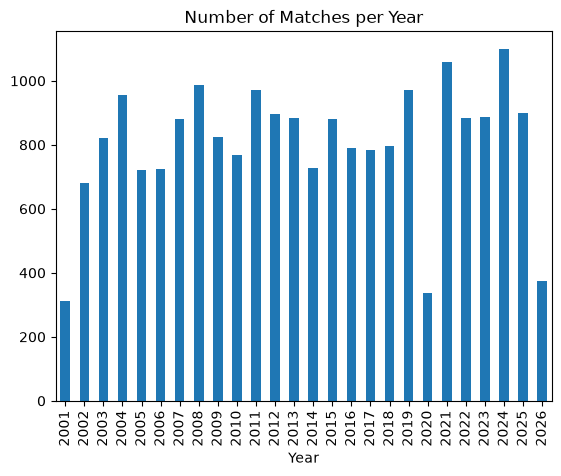

In [16]:
df['date'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Number of Matches per Year')
plt.xlabel('Year')


In [17]:
df[['home_score','away_score']].describe()

,home_score,away_score
count,20914.000000,20914.000000
mean,1.602276,1.089557
std,1.606628,1.296764
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,21.000000,21.000000


### Outliers

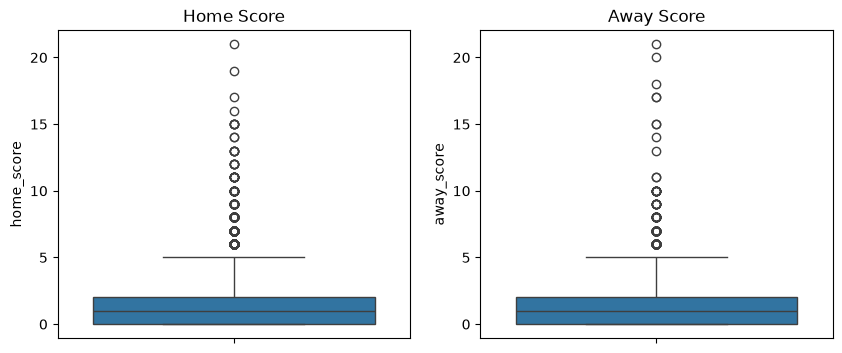

In [19]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.boxplot(y=df['home_score'], ax=axes[0])
sns.boxplot(y=df['away_score'], ax=axes[1])
axes[0].set_title('Home Score')
axes[1].set_title('Away Score')
plt.show()


I will not remove this outliers, as in Football they are real signals

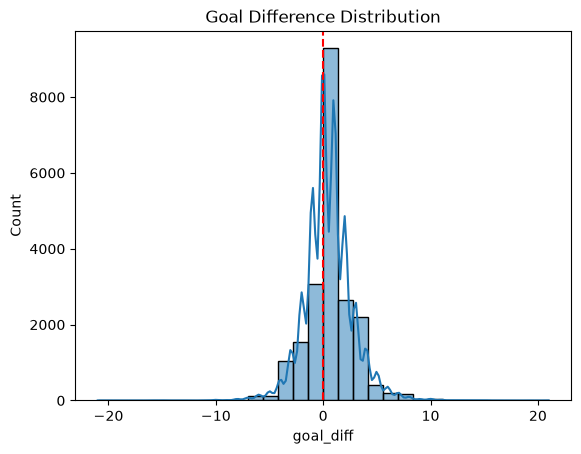

In [22]:
df['goal_diff'] = df['home_score'] - df['away_score']
sns.histplot(df['goal_diff'], bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Goal Difference Distribution')
plt.show()

In [25]:
df.to_csv(r'../data/processed/matches_merged_cleaned.csv', index=False)
print("Data Cleaned")

Data Cleaned
